1. Load final data
2. Load/train final model
3. SHAP explainability
4. Global feature importance
5. Individual fraud explanation
6. Fraud reasoning system
7. Final insights

# Explainable Fraud Intelligence using SHAP

This notebook focuses on explaining why the model predicts a review as fake or genuine.

The goal is to convert the machine learning model from a black-box classifier into an explainable fraud intelligence system.

In [24]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

In [2]:
train_df = pd.read_csv("../data/processed/train_processed.csv")
test_df = pd.read_csv("../data/processed/test_processed.csv")

target = "flagged"

features = [
    'rating',
    'restaurantRating',
    'rating_deviation',
    'friendCount',
    'reviewCount',
    'reviewUsefulCount',
    'usefulCount',
    'coolCount',
    'funnyCount',
    'complimentCount',
    'tipCount',
    'fanCount',
    'reviewer_account_age_days',
    'reviewer_engagement_ratio',
    'reviewer_social_reach',
    'reviewer_helpfulness_ratio',
    'reviewer_activity_level',
    'review_word_count'
]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print(X_train.shape)
print(X_test.shape)

(9929, 18)
(2483, 18)


In [3]:
final_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [25]:
final_threshold = 0.35

y_proba_final = final_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba_final >= final_threshold).astype(int)

print("Final Model Performance")
print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall   :", recall_score(y_test, y_pred_final))
print("F1 Score :", f1_score(y_test, y_pred_final))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_final))
print("PR-AUC   :", average_precision_score(y_test, y_proba_final))

Final Model Performance
Accuracy : 0.8896496173983085
Precision: 0.8393464942137508
Recall   : 0.970102281667978
F1 Score : 0.9
ROC-AUC  : 0.9488208655641331
PR-AUC   : 0.9346454861486387


In [5]:
explainer = shap.TreeExplainer(final_model)

shap_values = explainer.shap_values(X_test)

In [7]:
print(type(shap_values))
print(np.array(shap_values).shape)
print(X_test.shape)

<class 'numpy.ndarray'>
(2483, 18, 2)
(2483, 18)


In [8]:
shap_values_fake = shap_values[:, :, 1]

print(shap_values_fake.shape)
print(X_test.shape)

(2483, 18)
(2483, 18)


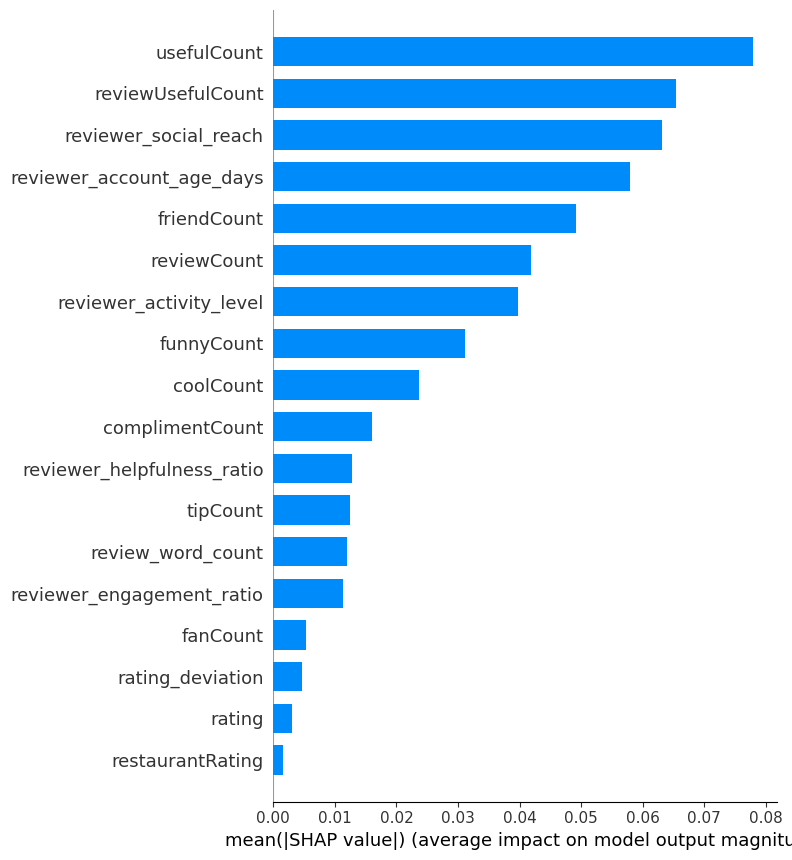

In [9]:
shap.summary_plot(
    shap_values_fake,
    X_test,
    plot_type="bar"
)

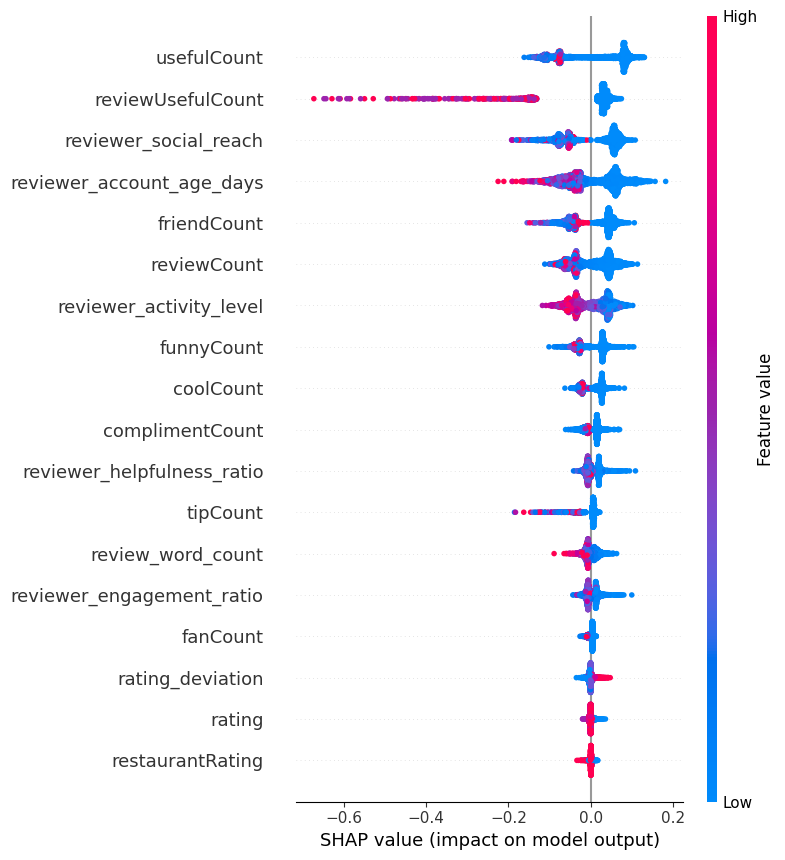

In [10]:
shap.summary_plot(
    shap_values_fake,
    X_test
)

In [11]:
sample_index = 0

print("Actual Label:", y_test.iloc[sample_index])
print("Fraud Probability:", y_proba_final[sample_index])
print("Final Prediction:", y_pred_final[sample_index])

Actual Label: 1
Fraud Probability: 0.9395711703915693
Final Prediction: 1


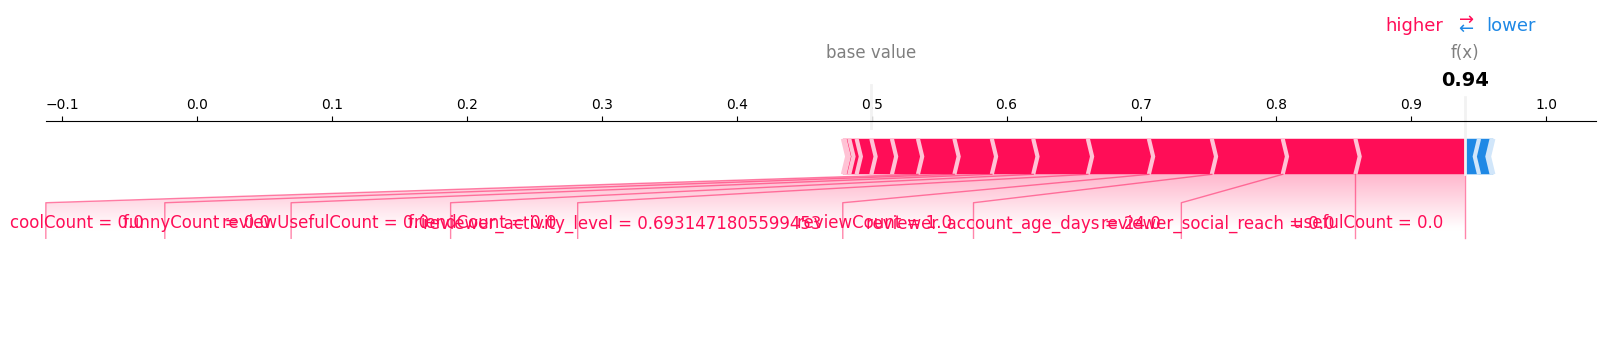

In [12]:
shap.force_plot(
    explainer.expected_value[1],
    shap_values_fake[sample_index],
    X_test.iloc[sample_index],
    matplotlib=True
)

In [13]:
sample_explanation = pd.DataFrame({
    "Feature": X_test.columns,
    "Feature Value": X_test.iloc[sample_index].values,
    "SHAP Impact": shap_values_fake[sample_index]
})

sample_explanation["Abs Impact"] = sample_explanation["SHAP Impact"].abs()

sample_explanation = sample_explanation.sort_values(
    by="Abs Impact",
    ascending=False
)

sample_explanation.head(10)

,Feature,Feature Value,SHAP Impact,Abs Impact
6,usefulCount,0.000000,0.081034,0.081034
14,reviewer_social_reach,0.000000,0.053870,0.053870
12,reviewer_account_age_days,24.000000,0.052560,0.052560
4,reviewCount,1.000000,0.046629,0.046629
16,reviewer_activity_level,0.693147,0.045217,0.045217
3,friendCount,0.000000,0.040468,0.040468
5,reviewUsefulCount,0.000000,0.030688,0.030688
8,funnyCount,0.000000,0.027737,0.027737
7,coolCount,0.000000,0.027014,0.027014
15,reviewer_helpfulness_ratio,0.000000,0.019291,0.019291


In [14]:
def explain_fraud_prediction(index, top_n=5):

    fraud_probability = y_proba_final[index]
    prediction = y_pred_final[index]

    sample_shap_values = shap_values_fake[index]
    sample_features = X_test.iloc[index]

    explanation_df = pd.DataFrame({
        "Feature": X_test.columns,
        "Feature Value": sample_features.values,
        "SHAP Impact": sample_shap_values
    })

    explanation_df["Abs Impact"] = explanation_df["SHAP Impact"].abs()

    explanation_df = explanation_df.sort_values(
        by="Abs Impact",
        ascending=False
    )

    print("Review Index:", index)
    print("Fraud Probability:", round(fraud_probability, 4))
    print("Prediction:", "Fake Review" if prediction == 1 else "Genuine Review")

    return explanation_df.head(top_n)

In [15]:
explain_fraud_prediction(0)

Review Index: 0
Fraud Probability: 0.9396
Prediction: Fake Review


,Feature,Feature Value,SHAP Impact,Abs Impact
6,usefulCount,0.000000,0.081034,0.081034
14,reviewer_social_reach,0.000000,0.053870,0.053870
12,reviewer_account_age_days,24.000000,0.052560,0.052560
4,reviewCount,1.000000,0.046629,0.046629
16,reviewer_activity_level,0.693147,0.045217,0.045217


In [16]:
def generate_fraud_reasons(index, top_n=5):

    explanation = explain_fraud_prediction(index, top_n)

    reasons = []

    for _, row in explanation.iterrows():

        feature = row["Feature"]
        value = row["Feature Value"]
        impact = row["SHAP Impact"]

        direction = "increased" if impact > 0 else "decreased"

        reason = f"{feature} = {round(value, 2)} {direction} the fake review probability."

        reasons.append(reason)

    return reasons

In [17]:
generate_fraud_reasons(0)

Review Index: 0
Fraud Probability: 0.9396
Prediction: Fake Review


['usefulCount = 0.0 increased the fake review probability.',
 'reviewer_social_reach = 0.0 increased the fake review probability.',
 'reviewer_account_age_days = 24.0 increased the fake review probability.',
 'reviewCount = 1.0 increased the fake review probability.',
 'reviewer_activity_level = 0.69 increased the fake review probability.']

In [18]:
generate_fraud_reasons(100)

Review Index: 100
Fraud Probability: 0.7526
Prediction: Fake Review


['usefulCount = 1.0 increased the fake review probability.',
 'review_word_count = 215.0 decreased the fake review probability.',
 'reviewer_social_reach = 0.0 increased the fake review probability.',
 'friendCount = 0.0 increased the fake review probability.',
 'reviewCount = 3.0 increased the fake review probability.']

In [19]:
def fraud_risk_level(probability):

    probability_percent = probability * 100

    if probability_percent < 30:
        return "Low Risk"

    elif probability_percent < 60:
        return "Medium Risk"

    elif probability_percent < 80:
        return "High Risk"

    else:
        return "Critical Risk"

In [20]:
fraud_risk_level(0.93)

'Critical Risk'

In [21]:
def fraud_intelligence_report(index, top_n=5):

    fraud_probability = y_proba_final[index]
    prediction = y_pred_final[index]

    risk_level = fraud_risk_level(fraud_probability)

    reasons = generate_fraud_reasons(index, top_n)

    print("=" * 60)

    print("REVIEW FRAUD INTELLIGENCE REPORT")

    print("=" * 60)

    print(f"Review Index       : {index}")
    print(f"Prediction         : {'Fake Review' if prediction == 1 else 'Genuine Review'}")
    print(f"Fraud Probability  : {round(fraud_probability * 100, 2)}%")
    print(f"Risk Level         : {risk_level}")

    print("\nTop Behavioral Reasons:")

    for i, reason in enumerate(reasons, start=1):
        print(f"{i}. {reason}")

    print("=" * 60)

In [22]:
fraud_intelligence_report(100)

Review Index: 100
Fraud Probability: 0.7526
Prediction: Fake Review
REVIEW FRAUD INTELLIGENCE REPORT
Review Index       : 100
Prediction         : Fake Review
Fraud Probability  : 75.26%
Risk Level         : High Risk

Top Behavioral Reasons:
1. usefulCount = 1.0 increased the fake review probability.
2. review_word_count = 215.0 decreased the fake review probability.
3. reviewer_social_reach = 0.0 increased the fake review probability.
4. friendCount = 0.0 increased the fake review probability.
5. reviewCount = 3.0 increased the fake review probability.


## Fraud Intelligence Report Results

The fraud intelligence report successfully combines:

- final model prediction
- fraud probability
- risk level classification
- SHAP-based behavioral explanations

The system can explain both fake and genuine predictions.

For suspicious reviews, the model highlights weak reviewer reputation signals such as:
- low useful count
- low social reach
- new reviewer account
- low review history
- low engagement activity

For genuine reviews, the model identifies trust-building signals such as:
- high useful count
- older account age
- higher review count
- stronger reviewer activity
- stronger community engagement

This makes the system interpretable, practical, and suitable for a fraud analytics dashboard.

In [23]:
import joblib

joblib.dump(final_model, "../models/final_random_forest_model.pkl")
joblib.dump(features, "../models/final_feature_list.pkl")
joblib.dump(final_threshold, "../models/final_threshold.pkl")

print("Final model, feature list, and threshold saved successfully.")

Final model, feature list, and threshold saved successfully.
